In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [59]:
filtered = pd.read_csv('bobcat_155_True_Active.csv')
unfiltered = pd.read_csv('bobcat_155_False_Active.csv')
# FILTERING BY PEOPLE WITH SUBJECT ID = 155 - 665 train, 214 valid, 215 test
# Parse comma-separated IDs
filtered['q_ids'] = filtered['sampled_q_ids'].str.split(',')
filtered['subj_ids'] = filtered['sampled_subject_ids'].str.split(',')
unfiltered['q_ids'] = unfiltered['sampled_q_ids'].str.split(',')
unfiltered['subj_ids'] = unfiltered['sampled_subject_ids'].str.split(',')

In [61]:
unfiltered

,user_id,sampled_q_ids,sampled_subject_ids,student_total_questions,q_ids,subj_ids
0,4540,"740,716,852,885,51,76,840,520,844,795","36,117,156,39,117,36,163,127,21,156",251,"[740, 716, 852, 885, 51, 76, 840, 520, 844, 795]","[36, 117, 156, 39, 117, 36, 163, 127, 21, 156]"
1,3507,"740,716,852,885,51,626,890,311,662,300","36,117,156,39,117,164,164,155,130,153",531,"[740, 716, 852, 885, 51, 626, 890, 311, 662, 300]","[36, 117, 156, 39, 117, 164, 164, 155, 130, 153]"
2,4932,"740,816,221,118,232,386,934,412,502,83","36,164,60,114,267,44,21,284,36,126",471,"[740, 816, 221, 118, 232, 386, 934, 412, 502, 83]","[36, 164, 60, 114, 267, 44, 21, 284, 36, 126]"
3,5784,"740,816,898,118,105,934,264,261,502,513","36,164,39,114,284,21,220,153,36,148",490,"[740, 816, 898, 118, 105, 934, 264, 261, 502, ...","[36, 164, 39, 114, 284, 21, 220, 153, 36, 148]"
4,5424,"740,816,852,885,675,790,898,118,51,76","36,164,156,39,165,148,39,114,117,36",535,"[740, 816, 852, 885, 675, 790, 898, 118, 51, 76]","[36, 164, 156, 39, 165, 148, 39, 114, 117, 36]"
...,...,...,...,...,...,...
210,3475,"740,816,790,125,852,898,754,118,105,934","36,164,148,54,156,39,155,114,284,21",547,"[740, 816, 790, 125, 852, 898, 754, 118, 105, ...","[36, 164, 148, 54, 156, 39, 155, 114, 284, 21]"
211,2062,"740,816,898,118,790,934,289,261,502,830","36,164,39,114,148,21,146,153,36,148",380,"[740, 816, 898, 118, 790, 934, 289, 261, 502, ...","[36, 164, 39, 114, 148, 21, 146, 153, 36, 148]"
212,3456,"740,816,852,885,675,51,626,890,311,662","36,164,156,39,165,117,164,164,155,130",545,"[740, 816, 852, 885, 675, 51, 626, 890, 311, 662]","[36, 164, 156, 39, 165, 117, 164, 164, 155, 130]"
213,2726,"740,816,790,125,852,540,675,51,626,890","36,164,148,54,156,54,165,117,164,164",546,"[740, 816, 790, 125, 852, 540, 675, 51, 626, 890]","[36, 164, 148, 54, 156, 54, 165, 117, 164, 164]"


In [25]:
all_subj_filtered = [s for subj_list in filtered['subj_ids'] for s in subj_list]
all_subj_unfiltered = [s for subj_list in unfiltered['subj_ids'] for s in subj_list]

subj_counts_f = pd.Series(all_subj_filtered).value_counts()
subj_counts_u = pd.Series(all_subj_unfiltered).value_counts()

comparison = pd.DataFrame({
    'Filtered': subj_counts_f,
    'Unfiltered': subj_counts_u
}).fillna(0).astype(int)
comparison['Difference'] = abs(comparison['Filtered'] - comparison['Unfiltered'])
comparison2 = comparison.sort_values('Difference', ascending=False)
print(comparison.head(20))
print("="*40)
print(comparison2.head(20))

     Filtered  Unfiltered  Difference
114         0         154         154
117         0         170         170
125         4           0           4
126         0          26          26
127         0          18          18
128         0           1           1
129         0           3           3
130         0           7           7
135         0           2           2
137       117          10         107
146         0          33          33
148       206         115          91
153         0          29          29
155        52          32          20
156       553         136         417
163       197          54         143
164        94         269         175
165         1          74          73
168         0           4           4
169         1           0           1
     Filtered  Unfiltered  Difference
156       553         136         417
36          0         291         291
3         260          20         240
39          0         226         226
189       21

In [26]:
# 2. Per-student overlap
overlaps = []
for _, f_row in filtered.iterrows():
    u_row = unfiltered[unfiltered['user_id'] == f_row['user_id']]
    if not u_row.empty:
        u_row = u_row.iloc[0]
        
        q_f = set(f_row['q_ids'])
        q_u = set(u_row['q_ids'])
        s_f = set(f_row['subj_ids'])
        s_u = set(u_row['subj_ids'])
        
        overlaps.append({
            'user_id': f_row['user_id'],
            'q_overlap': len(q_f & q_u),
            'q_overlap_pct': len(q_f & q_u) / len(q_f) * 100,
            's_overlap': len(s_f & s_u),
            's_overlap_pct': len(s_f & s_u) / len(s_f) * 100
        })

overlap_df = pd.DataFrame(overlaps)

print(f"Average Question Overlap: {overlap_df['q_overlap_pct'].mean():.1f}%")
print(f"Average Subject Overlap: {overlap_df['s_overlap_pct'].mean():.1f}%")
print(f"\nStudents analyzed: {len(overlap_df)}")


Average Question Overlap: 0.1%
Average Subject Overlap: 27.4%

Students analyzed: 215


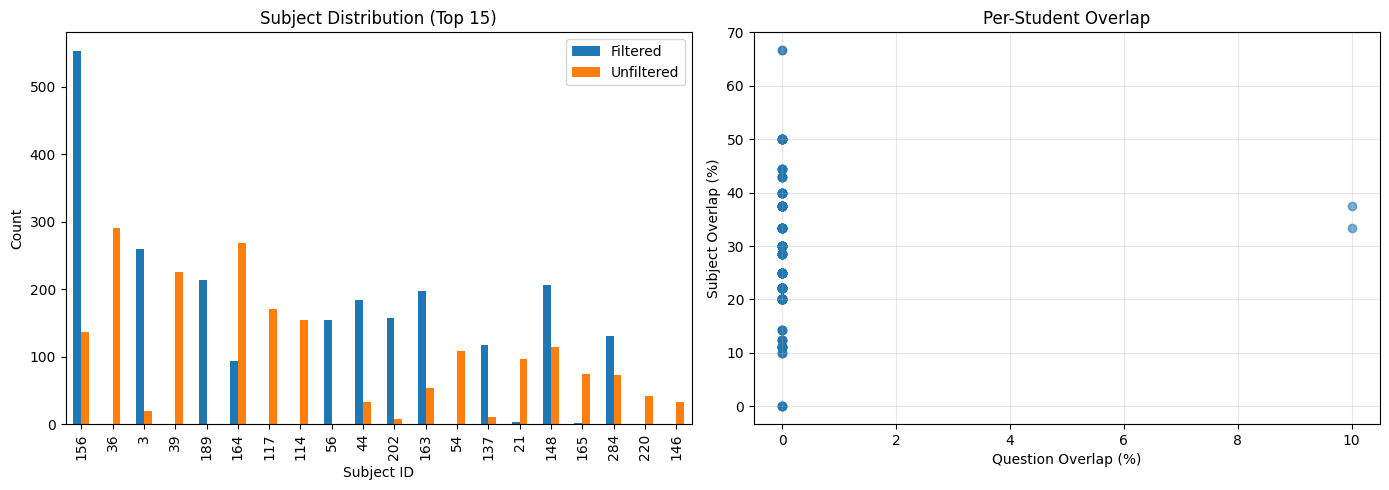

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subject distribution
top_subjects = comparison2.head(20)
top_subjects[['Filtered', 'Unfiltered']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Subject Distribution (Top 15)')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Count')
axes[0].legend(['Filtered', 'Unfiltered'])

# Overlap scatter
axes[1].scatter(overlap_df['q_overlap_pct'], overlap_df['s_overlap_pct'], alpha=0.6)
axes[1].set_xlabel('Question Overlap (%)')
axes[1].set_ylabel('Subject Overlap (%)')
axes[1].set_title('Per-Student Overlap')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

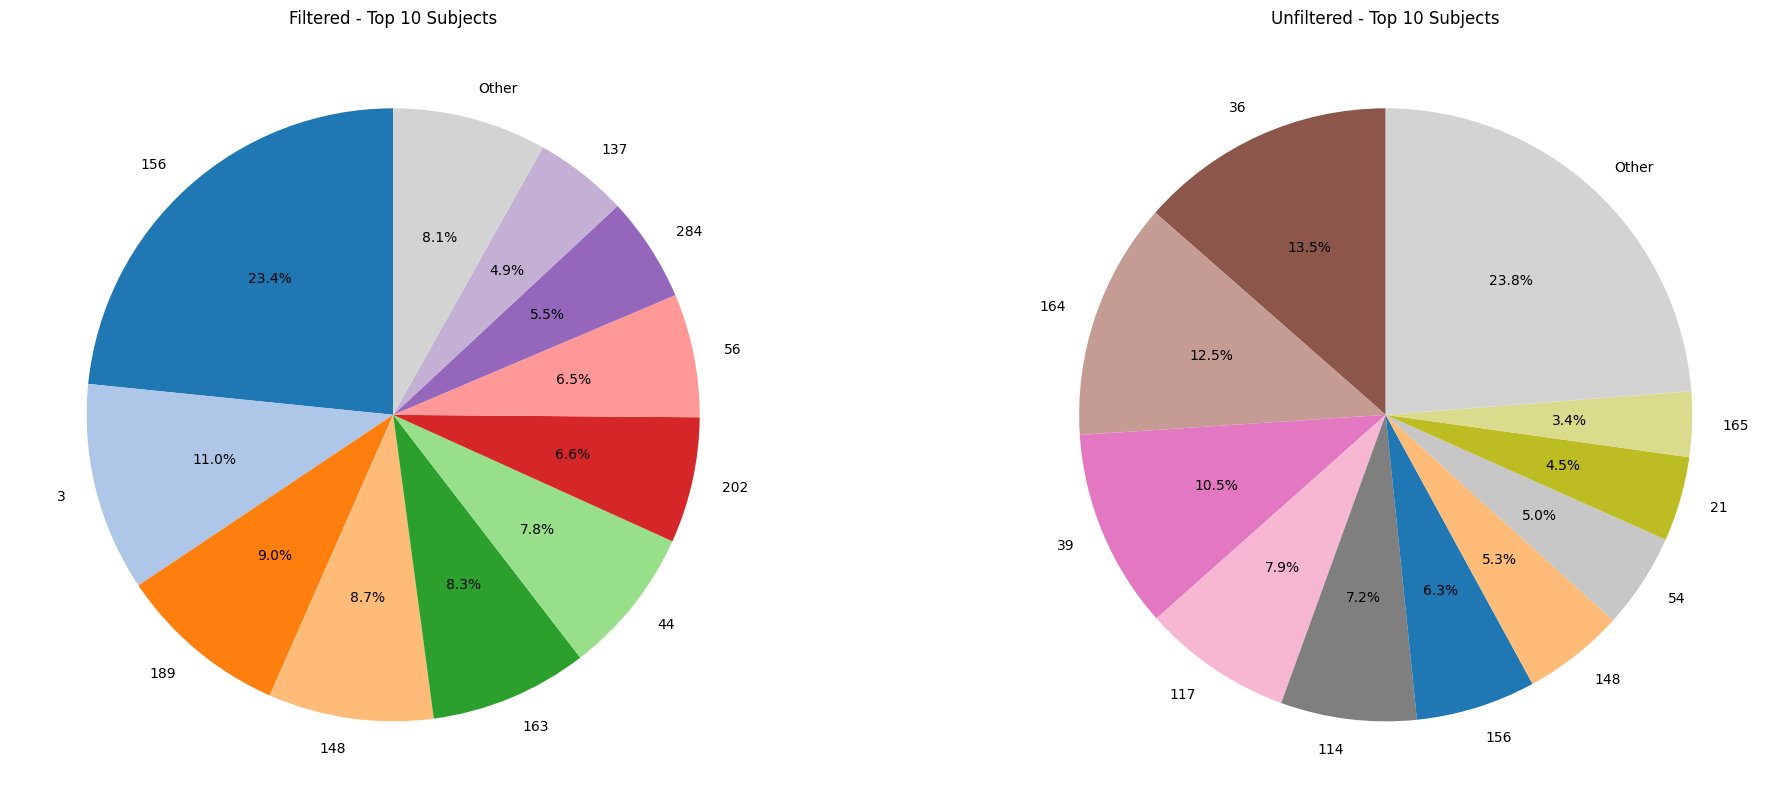

In [17]:
fig = plt.figure(figsize=(20, 16))
top_n = 10

# Get all unique subjects from both datasets and create color map
all_top_subjects = pd.concat([subj_counts_f.head(top_n), subj_counts_u.head(top_n)]).index.unique()
colors = plt.cm.tab20(range(len(all_top_subjects)))
color_map = {subj: colors[i] for i, subj in enumerate(all_top_subjects)}
color_map['Other'] = 'lightgray'

# Filtered pie
ax3 = plt.subplot(2, 2, 3)
top_filtered = subj_counts_f.head(top_n)
other_filtered = subj_counts_f.iloc[top_n:].sum()
pie_filtered = pd.concat([top_filtered, pd.Series({'Other': other_filtered})])
filtered_colors = [color_map.get(subj, 'gray') for subj in pie_filtered.index]
ax3.pie(pie_filtered, labels=pie_filtered.index, autopct='%1.1f%%', startangle=90, colors=filtered_colors)
ax3.set_title(f'Filtered - Top {top_n} Subjects')

# Unfiltered pie
ax4 = plt.subplot(2, 2, 4)
top_unfiltered = subj_counts_u.head(top_n)
other_unfiltered = subj_counts_u.iloc[top_n:].sum()
pie_unfiltered = pd.concat([top_unfiltered, pd.Series({'Other': other_unfiltered})])
unfiltered_colors = [color_map.get(subj, 'gray') for subj in pie_unfiltered.index]
ax4.pie(pie_unfiltered, labels=pie_unfiltered.index, autopct='%1.1f%%', startangle=90, colors=unfiltered_colors)
ax4.set_title(f'Unfiltered - Top {top_n} Subjects')

plt.tight_layout()
plt.show()

## Connecting with train_task_3_4 and q_id_to_subjects_mapping.csv

In [18]:
# Load the train task JSON file
with open('../data/train_task_3_4.json', 'r') as f:
    train_data = json.load(f)

# Load the question ID to subjects mapping
q_id_mapping = pd.read_csv('../data/q_id_to_subjects_mapping.csv')

# Create a dictionary mapping student_id to all their question IDs
student_to_questions = {}
for entry in train_data:
    student_id = entry['user_id']
    
    # Handle question_id - could be a list string or a single value
    question_id = entry['q_ids']
    if isinstance(question_id, str) and question_id.startswith('['):
        # It's a stringified list, parse it
        question_ids = json.loads(question_id)
    elif isinstance(question_id, list):
        question_ids = question_id
    else:
        question_ids = [question_id]
    
    if student_id not in student_to_questions:
        student_to_questions[student_id] = []
    student_to_questions[student_id].extend([str(qid) for qid in question_ids])

# Create a dictionary mapping question_id to subject_ids
q_id_to_subjects = {}
for _, row in q_id_mapping.iterrows():
    q_id = str(row['q_id'])
    
    # Handle subject_id - could be a list string or a single value
    subject_id = row['subject_ids']
    if isinstance(subject_id, str) and subject_id.startswith('['):
        # It's a stringified list, parse it
        subject_ids = json.loads(subject_id)
    elif isinstance(subject_id, list):
        subject_ids = subject_id
    else:
        subject_ids = [subject_id]
    
    if q_id not in q_id_to_subjects:
        q_id_to_subjects[q_id] = []
    q_id_to_subjects[q_id].extend([str(sid) for sid in subject_ids])



In [21]:
# Function to get all available questions and subjects for a student
def get_available_data(student_id):
    if student_id not in student_to_questions:
        return [], []
    
    all_q_ids = student_to_questions[student_id]
    all_subj_ids = []
    
    for q_id in all_q_ids:
        if q_id in q_id_to_subjects:
            all_subj_ids.append(q_id_to_subjects[q_id])
        else:
            all_subj_ids.append([])  # Empty list if no subjects found for this question
    
    return all_q_ids, all_subj_ids

# Add columns to filtered dataframe (using user_id, not SubjectID)
filtered['available_q_ids'] = filtered['user_id'].apply(
    lambda uid: get_available_data(uid)[0]
)
filtered['available_subject_ids'] = filtered['user_id'].apply(
    lambda uid: get_available_data(uid)[1]
)

# Add columns to unfiltered dataframe
unfiltered['available_q_ids'] = unfiltered['user_id'].apply(
    lambda uid: get_available_data(uid)[0]
)
unfiltered['available_subject_ids'] = unfiltered['user_id'].apply(
    lambda uid: get_available_data(uid)[1]
)

In [22]:
filtered.iloc[0]

user_id                                                                 4540
sampled_q_ids                                    2,6,11,18,24,27,29,30,31,34
sampled_subject_ids                 3,156,148,156,156,156,175,156,21,156,156
student_total_questions                                                  251
q_ids                                 [2, 6, 11, 18, 24, 27, 29, 30, 31, 34]
subj_ids                   [3, 156, 148, 156, 156, 156, 175, 156, 21, 156...
available_q_ids            [199, 911, 764, 405, 754, 461, 650, 314, 678, ...
available_subject_ids      [[155], [154], [155], [154], [155], [155], [15...
Name: 0, dtype: object

In [23]:
len(filtered.iloc[0]["available_q_ids"])
len(filtered.iloc[0]["available_subject_ids"])

251

In [24]:
filtered.iloc[0]["available_subject_ids"]

[['155'],
 ['154'],
 ['155'],
 ['154'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['3', '156'],
 ['156'],
 ['155'],
 ['156'],
 ['155'],
 ['156'],
 ['155'],
 ['154'],
 ['155'],
 ['154'],
 ['155'],
 ['154'],
 ['154'],
 ['154'],
 ['154'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['39'],
 ['39'],
 ['39'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['155'],
 ['156'],
 ['155'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['39'],
 ['39'],
 ['39'],
 ['39'],
 ['33'],
 ['33'],
 ['39'],
 ['33'],
 ['114'],
 ['114'],
 ['36'],
 ['36'],
 ['36'],
 ['36'],
 ['36'],
 ['36'],
 ['36'],
 ['36'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['156'],
 ['1

In [41]:
unfiltered["num_subjects"] = unfiltered["sampled_subject_ids"].str.split(",").apply(set).apply(len)

In [40]:
filtered["num_subjects"] = filtered["sampled_subject_ids"].str.split(",").apply(set).apply(len)

(0.0, 1.0)

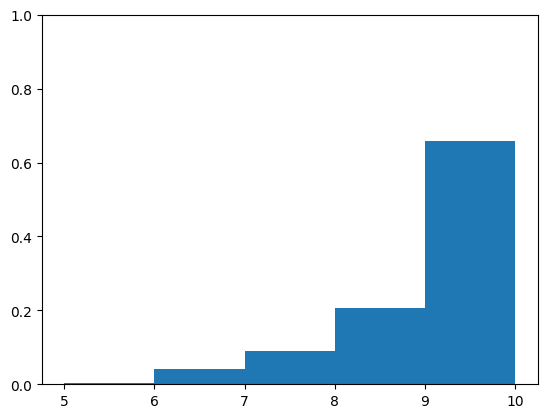

In [57]:
plt.hist(filtered["num_subjects"], density = True, bins=range(5,11))
plt.ylim([0,1])

(0.0, 1.0)

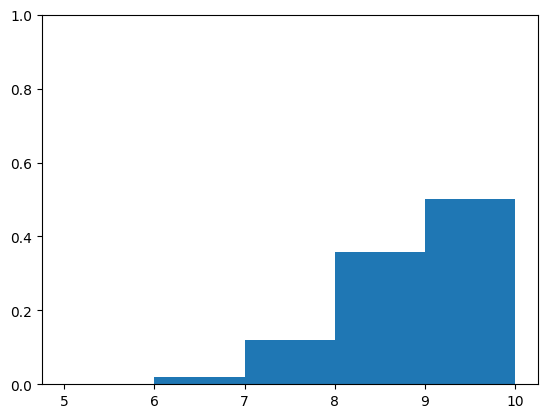

In [58]:
plt.hist(unfiltered["num_subjects"], density = True, bins=range(5,11))
plt.ylim([0,1])

In [85]:
filtered.head()

,user_id,sampled_q_ids,sampled_subject_ids,student_total_questions,q_ids,subj_ids
0,4540,"2,6,11,18,24,27,29,30,31,34","3,156,148,156,156,156,175,156,21,156,156",251,"[2, 6, 11, 18, 24, 27, 29, 30, 31, 34]","[3, 156, 148, 156, 156, 156, 175, 156, 21, 156..."
1,3507,"0,2,4,6,8,10,11,14,16,18","189,3,156,56,148,163,202,156,137,164,156",531,"[0, 2, 4, 6, 8, 10, 11, 14, 16, 18]","[189, 3, 156, 56, 148, 163, 202, 156, 137, 164..."
2,4932,"2,6,8,10,11,14,16,18,19,23","3,156,148,163,202,156,137,164,156,3,125",471,"[2, 6, 8, 10, 11, 14, 16, 18, 19, 23]","[3, 156, 148, 163, 202, 156, 137, 164, 156, 3,..."
3,5784,"0,2,4,6,8,11,12,13,14,16","189,3,156,56,148,163,156,284,44,137,164",490,"[0, 2, 4, 6, 8, 11, 12, 13, 14, 16]","[189, 3, 156, 56, 148, 163, 156, 284, 44, 137,..."
4,5424,"0,2,4,6,8,10,11,12,14,16","189,3,156,56,148,163,202,156,284,137,164",535,"[0, 2, 4, 6, 8, 10, 11, 12, 14, 16]","[189, 3, 156, 56, 148, 163, 202, 156, 284, 137..."


In [86]:
unfiltered.head()

,user_id,sampled_q_ids,sampled_subject_ids,student_total_questions,q_ids,subj_ids
0,4540,"740,716,852,885,51,76,840,520,844,795","36,117,156,39,117,36,163,127,21,156",251,"[740, 716, 852, 885, 51, 76, 840, 520, 844, 795]","[36, 117, 156, 39, 117, 36, 163, 127, 21, 156]"
1,3507,"740,716,852,885,51,626,890,311,662,300","36,117,156,39,117,164,164,155,130,153",531,"[740, 716, 852, 885, 51, 626, 890, 311, 662, 300]","[36, 117, 156, 39, 117, 164, 164, 155, 130, 153]"
2,4932,"740,816,221,118,232,386,934,412,502,83","36,164,60,114,267,44,21,284,36,126",471,"[740, 816, 221, 118, 232, 386, 934, 412, 502, 83]","[36, 164, 60, 114, 267, 44, 21, 284, 36, 126]"
3,5784,"740,816,898,118,105,934,264,261,502,513","36,164,39,114,284,21,220,153,36,148",490,"[740, 816, 898, 118, 105, 934, 264, 261, 502, ...","[36, 164, 39, 114, 284, 21, 220, 153, 36, 148]"
4,5424,"740,816,852,885,675,790,898,118,51,76","36,164,156,39,165,148,39,114,117,36",535,"[740, 816, 852, 885, 675, 790, 898, 118, 51, 76]","[36, 164, 156, 39, 165, 148, 39, 114, 117, 36]"


In [82]:
filtered["sampled_q_ids"].str.split(",").apply(
    lambda x: x[0]
).value_counts()

sampled_q_ids
0    194
2     20
6      1
Name: count, dtype: int64

In [83]:
unfiltered["sampled_q_ids"].str.split(",").apply(
    lambda x: x[0]
).value_counts()

sampled_q_ids
740    203
852      8
816      2
716      2
Name: count, dtype: int64